In [1]:
from wyckoff_transformer.evaluation.generated_dataset import load_all_from_config, GeneratedDataset
import pandas as pd

In [2]:
train_val_ = load_all_from_config(datasets=[("split", "train"), ("split", "val")])
train_val = pd.concat((d.data for d in train_val_.values()), axis=0, ignore_index=False)

In [3]:
test = GeneratedDataset.from_cache(("split", "test")).data

In [4]:
wt = GeneratedDataset.from_cache(("WyckoffTransformer", )).data.sample(len(test), random_state=42)

In [5]:
from collections import Counter

In [6]:
def collect_tokens(fingerprint):
    return sum((Counter(dict(fs)) for fs in fingerprint[1]), Counter())

def record_to_token_counter(row):
    """
    Produces a non-augmented token counter from a row
    """
    return Counter(
        map(tuple, zip(row["elements"], row["site_symmetries"], row["sites_enumeration"])))

In [7]:
test_token_counts = test.apply(record_to_token_counter, axis=1).sum()

In [8]:
augmented_test_token_counts = test.fingerprint.apply(collect_tokens).sum()

In [9]:
train_val_token_counts = train_val.fingerprint.apply(collect_tokens).sum()

In [10]:
wt_token_counts = wt.apply(record_to_token_counter, axis=1).sum()

In [11]:
len(test)

9046

In [12]:
len(test_token_counts.keys() - train_val_token_counts.keys())

202

1. There are no precise details on how many tokens were formed from the MP-20 dataset after tokenization. It would be interesting to discuss this number and other statistics about the tokens, e.g., which tokens are present more often (for some of the high symmetry space groups) and how the distribution of tokens affects training.

In [13]:
mp_20_token_counts = augmented_test_token_counts + train_val_token_counts

In [14]:
len(mp_20_token_counts)

10997

In [15]:
mp_20_token_freq_pd = pd.Series(mp_20_token_counts).sort_values(ascending=False)
mp_20_token_freq_pd /= mp_20_token_freq_pd.sum()

/home/kna/.cache/pypoetry/virtualenvs/wyckofftransformer-FeCwefly-py3.12/lib/python3.12/site-packages/pymatgen/core/periodic_table.py:257: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  x1 = float("inf") if self.X != self.X else self.X
/home/kna/.cache/pypoetry/virtualenvs/wyckofftransformer-FeCwefly-py3.12/lib/python3.12/site-packages/pymatgen/core/periodic_table.py:255: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  if not hasattr(other, "X") or not hasattr(other, "symbol"):
/home/kna/.cache/pypoetry/virtualenvs/wyckofftransformer-FeCwefly-py3.12/lib/python3.12/site-packages/pymatgen/core/periodic_table.py:258: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors 

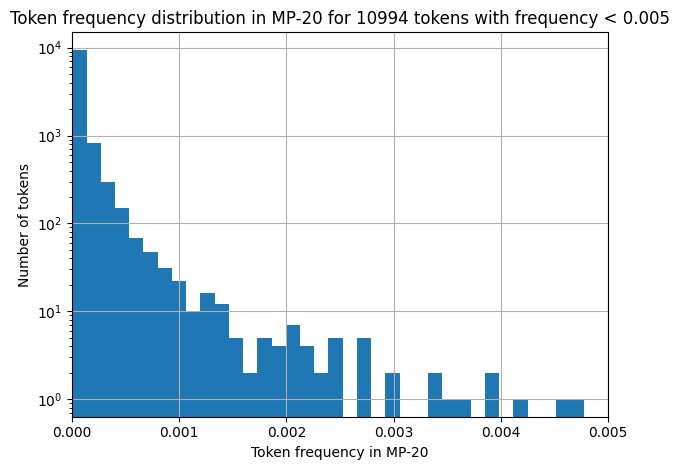

In [16]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots()
mp_20_token_freq_pd.hist(bins=500, ax=ax)
threshold = 0.005
ax.set_xlim(0, threshold)
ax.set_xlabel("Token frequency in MP-20")
ax.set_ylabel("Number of tokens")
ax.set_yscale("log")
ax.set_title(f"Token frequency distribution in MP-20 for {(mp_20_token_freq_pd < 0.01).sum()} tokens with frequency < {threshold}")
fig.tight_layout()
fig.savefig("mp_20_token_hist.pdf")

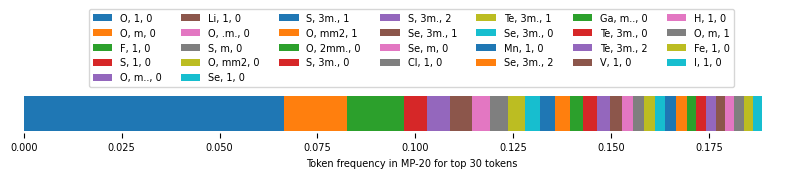

In [17]:
import matplotlib
import matplotlib.pyplot as plt
font = {'size': 7}
matplotlib.rc('font', **font)
fig, ax = plt.subplots(figsize=(10, 0.5))
start = 0
top_count = 30
cmap = matplotlib.colormaps['tab10']
for i, (token, frequency) in enumerate(mp_20_token_freq_pd.iloc[:top_count].items()):
    ax.barh(0, frequency, left=start, color=cmap(i % cmap.N), label=f"{token[0]}, {token[1]}, {token[2]}")
    start += frequency
ax.set_yticks([])
ax.set_xlabel(f"Token frequency in MP-20 for top {top_count} tokens")
legend = ax.legend(ncol=7, bbox_to_anchor=(0.5, 2.2), loc='center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
fig.savefig("mp_20_token_top.pdf", bbox_extra_artists=(legend,), bbox_inches='tight')

2. It is also important to add how many new tokens the method generates or if it just predicts the fixed set of tokens in different combinations (and these combinations result in more template novelty than just sampling existing templates from training data). For instance, naively thinking about it, how will your model generate tokens that are not present in its dictionary?


In [18]:
print(len(wt_token_counts.keys() - train_val_token_counts.keys()), len(test_token_counts.keys() - train_val_token_counts.keys()))

796 202


In [19]:
len(wt_token_counts.keys() - train_val_token_counts.keys())/len(wt)*28

2.463851426044661

3. Another thing is that the token space is relatively smaller, so how can it be argued that these tokens cover all possible values a token could take in real material? Since we do not expect to see new tokens during generation, it should be added as a limitation of the method.

In [20]:
(wt_token_counts - train_val_token_counts).most_common(10)

[((Element Cu, '-6m2', 1), 13),
 ((Element Zr, '3.2', 0), 12),
 ((Element B, '-6m2', 1), 12),
 ((Element Ge, '-6m2', 1), 12),
 ((Element Ni, '-6m2', 1), 11),
 ((Element Zn, '-6m2', 1), 10),
 ((Element Ga, '-6m2', 1), 10),
 ((Element Pd, '-62m', 0), 10),
 ((Element In, '-6m2', 2), 9),
 ((Element Rh, '-62m', 0), 9)]

In [21]:
len(wt)-wt.fingerprint.isin(train_val.fingerprint).sum()

8265

In [22]:
75*81*8

48600